## Example the correction result

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def show_distribution_log_scale(array, title):
	fig, ax = plt.subplots(figsize=(8, 4))
	ax.hist(array.ravel(), bins=1000, color='gray')
	ax.set_title(title)
	ax.set_xlabel('Pixel Intensity')
	ax.set_ylabel('Frequency')
	ax.set_yscale('log')
	ax.grid(False)
	plt.show()

def img_show(array, title):
	# Calculate mean along each axis
	mean_x_axis = np.mean(array, axis=0) # Mean along columns
	mean_y_axis = np.mean(array, axis=1) # Mean along rows

	# Create subplots
	fig, ax = plt.subplots(1, 3, figsize=(12, 4)) # One row, three columns

	# Plot the image
	im = ax[0].imshow(array, cmap='rainbow') # Display image in 'rainbow' colormap
	ax[0].set_title('Original Image')
	ax[0].set_xlabel('X-axis (Columns)')
	ax[0].set_ylabel('Y-axis (Rows)')
	fig.colorbar(im, ax=ax[0], orientation='vertical', label='Intensity')


	# Plot the mean along the X-axis
	ax[1].plot(mean_x_axis)
	ax[1].set_title('Mean along X-axis')
	ax[1].set_xlabel('X-axis (Columns)')
	ax[1].set_ylabel('Mean Intensity')

	# Plot the mean along the Y-axis
	ax[2].plot(mean_y_axis, range(len(mean_y_axis))) # Plot against y-axis indices
	ax[2].set_title('Mean along Y-axis')
	ax[2].set_xlabel('Mean Intensity')
	ax[2].set_ylabel('Y-axis (Rows)')
	ax[2].invert_yaxis() # Invert y-axis to match image orientation

	plt.suptitle(title, fontsize=16)
	plt.tight_layout()
	plt.show()



def img_show_surface(
        array,
        title: str = "Surface",
        rstride: int = 10,
        cstride: int = 10,
        vmin=None,
        vmax=None,
        downsample: int = 1
    ):
    """
    Plot a 3‑D surface of a 2‑D NumPy array.

    Parameters
    ----------
    array : np.ndarray
        A 2‑D array (shape ``(m, n)``).  The values are plotted as the z‑axis.
    title : str, optional
        Window / plot title. Default: "Surface".
    cmap : str or Colormap, optional
        Matplotlib colormap used for the surface colours.
    rstride : int, optional
        Row stride – how many rows to skip when drawing the mesh.
        Useful for very dense data; default is 1 (draw every row).
    cstride : int, optional
        Column stride – analogous to ``rstride`` but along columns.
    vmin, vmax : float, optional
        Minimum / maximum values used for colour scaling. If omitted,
        the min/max of ``data`` are used automatically.
    downsample : int, optional
        Factor by which to subsample *both* axes before plotting.
        Setting this to 2 will keep every other row and column (effectively a
        4‑fold reduction in point count).  This is handy for huge images
        such as 2560×2048 where drawing the full grid would be slow.

    Returns
    -------
    fig, ax : matplotlib.figure.Figure, mpl_toolkits.mplot3d.Axes3D
        The figure and axes objects – you can further customise them if
        desired (e.g. add text, change limits, etc.).

    Notes
    -----
    * For a 2560×2048 array the full surface has ~5 million points.
      Plotting that many triangles is expensive; try ``downsample=2`` or
      use larger strides to keep the plot snappy.
    * If you need an interactive, high‑performance viewer for very large
      data sets consider using **Plotly** or **Mayavi** (see the short example
      below).
    """
    # ---- sanity checks -------------------------------------------------
    if not isinstance(array, np.ndarray):
        raise TypeError("data must be a NumPy array")
    if array.ndim != 2:
        raise ValueError("data must be 2‑D")

    # ---- optional down‑sampling ----------------------------------------
    if downsample > 1:
        array = array[::downsample, ::downsample]
        rstride = max(1, rstride // downsample)
        cstride = max(1, cstride // downsample)

    m, n = array.shape

    # ---- coordinate grid (x → columns, y → rows) -----------------------
    x = np.arange(n)          # horizontal axis
    y = np.arange(m)          # vertical axis
    X, Y = np.meshgrid(x, y)

    # ---- plot ----------------------------------------------------------
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        -X,
        Y,
        array,
        rstride=rstride,
        cstride=cstride,
        cmap="rainbow",
        linewidth=0,
        antialiased=False,
        vmin=vmin,
        vmax=vmax
    )

    # ---- aesthetics ----------------------------------------------------
    ax.set_xlabel("X (columns)")
    ax.set_ylabel("Y (rows)")
    ax.set_zlabel("Z value")
    ax.set_title(title)
    ax.view_init(elev=30, azim=150, roll=0)


    fig.colorbar(surf, shrink=0.5, aspect=10, label='Z')
    plt.tight_layout()
    plt.show()

    return fig, ax



## correction algorithm

In [12]:
# replaced by a package

import dexa_correction

## Show the correction array

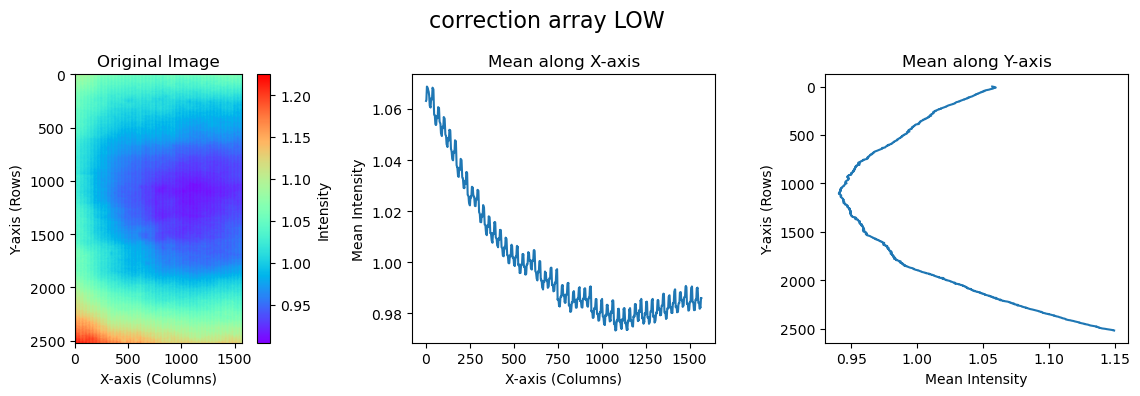

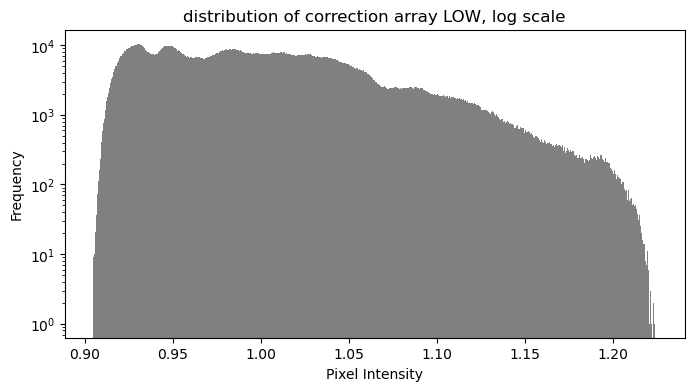

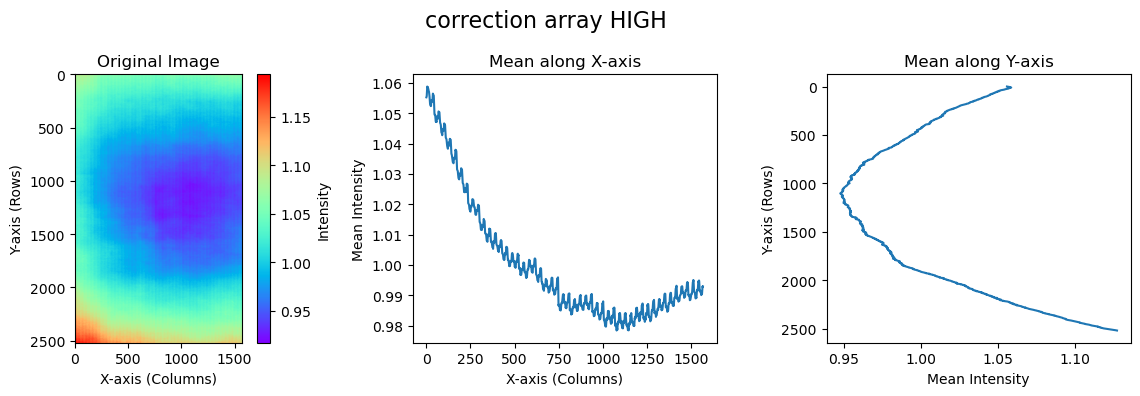

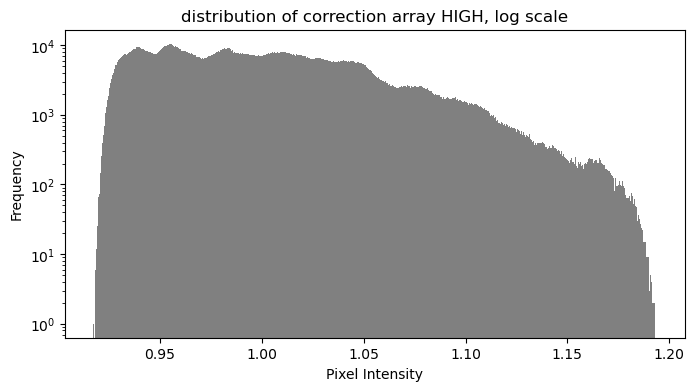

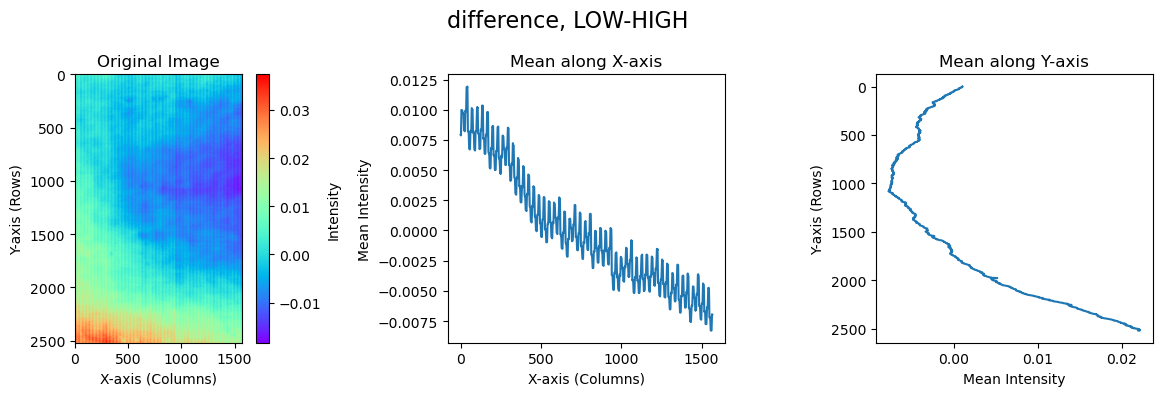

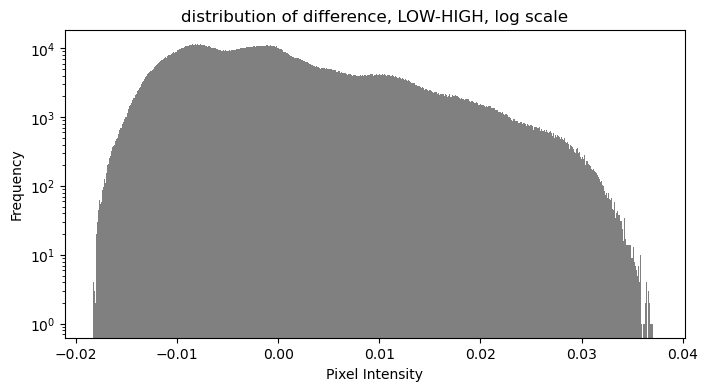

In [13]:
IMAGE_HEIGHT = 2560 - 20 - 20
IMAGE_WIDTH = 2048 - 20 - 460

array_correction_low = np.loadtxt("output/correction_low.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)
array_correction_high = np.loadtxt("output/correction_high.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_correction_low, "correction array LOW")
show_distribution_log_scale(array_correction_low, "distribution of correction array LOW, log scale")
img_show(array_correction_high, "correction array HIGH")
show_distribution_log_scale(array_correction_high, "distribution of correction array HIGH, log scale")

array_difference = array_correction_low - array_correction_high
img_show(array_difference, "difference, LOW-HIGH")
show_distribution_log_scale(array_difference, "distribution of difference, LOW-HIGH, log scale")


## Show example corrected image

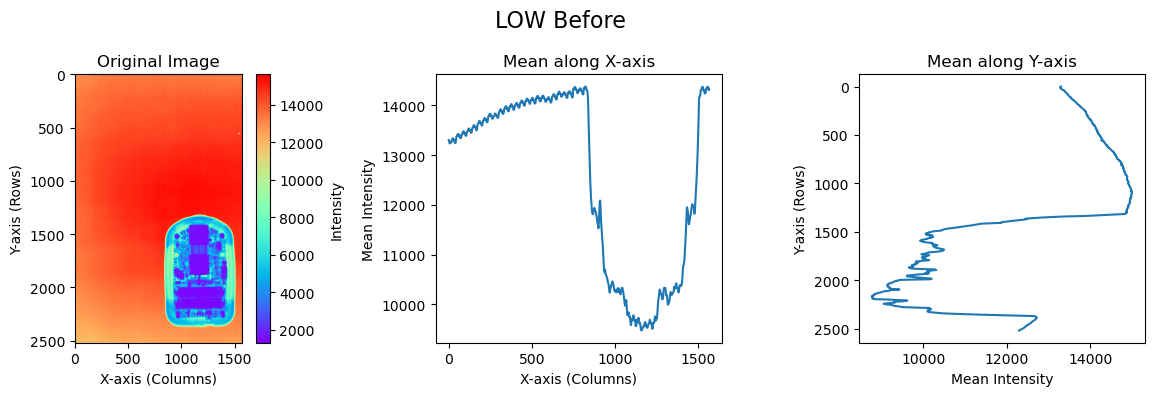

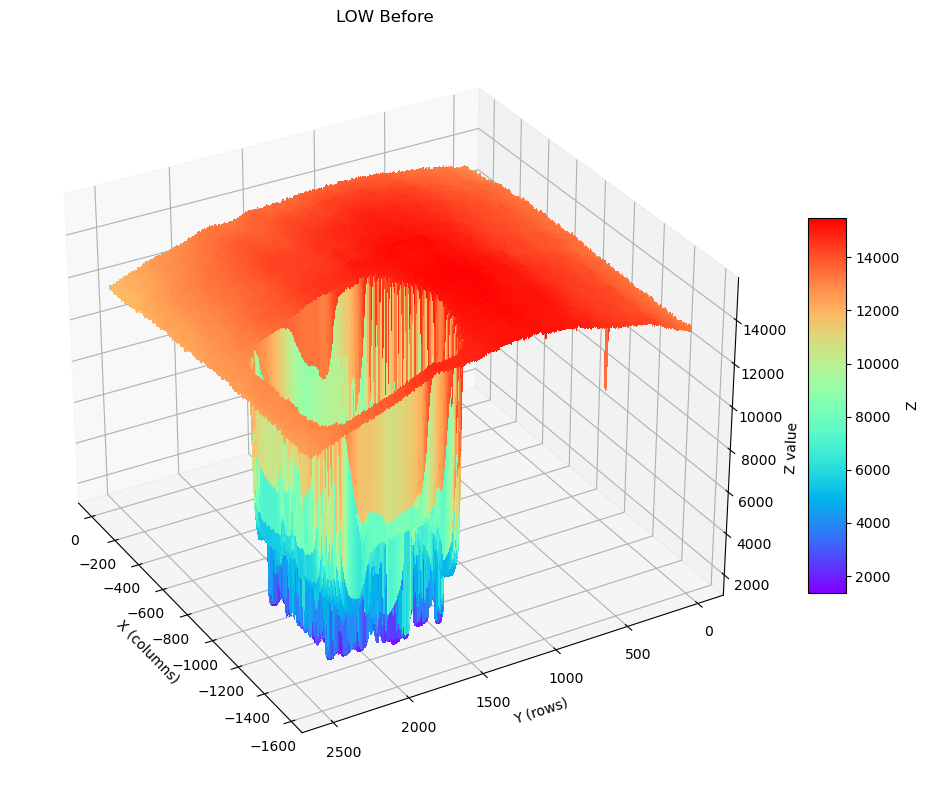

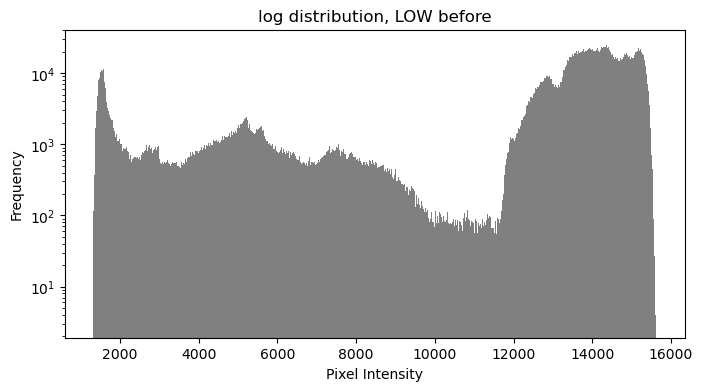

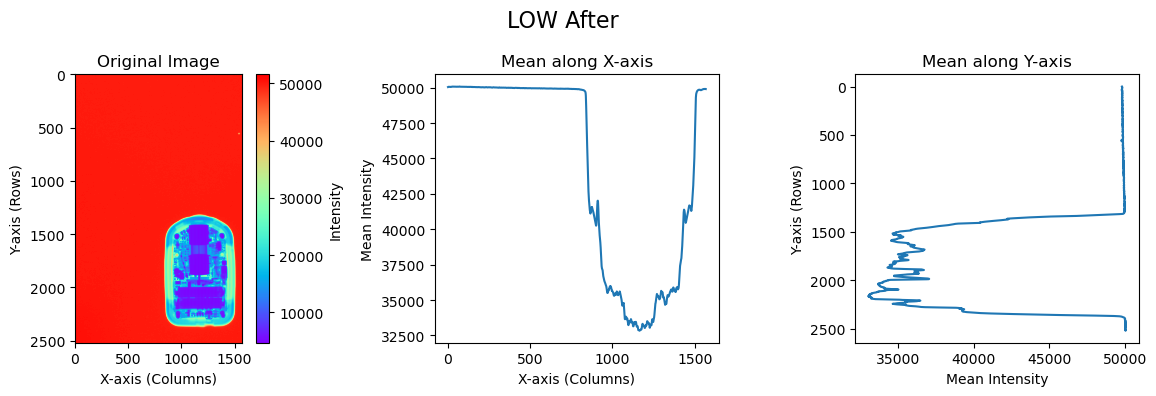

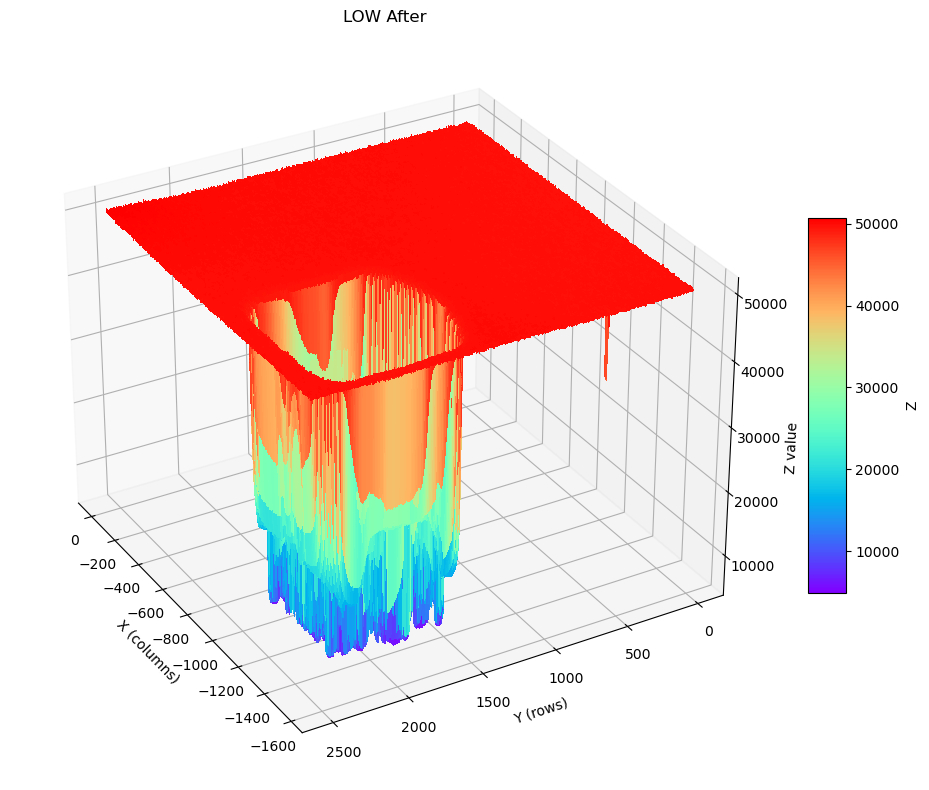

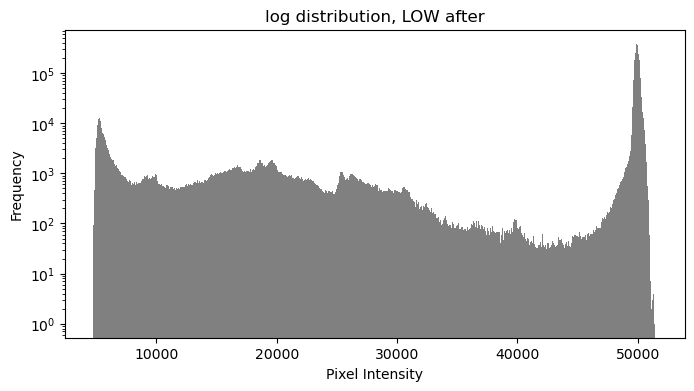

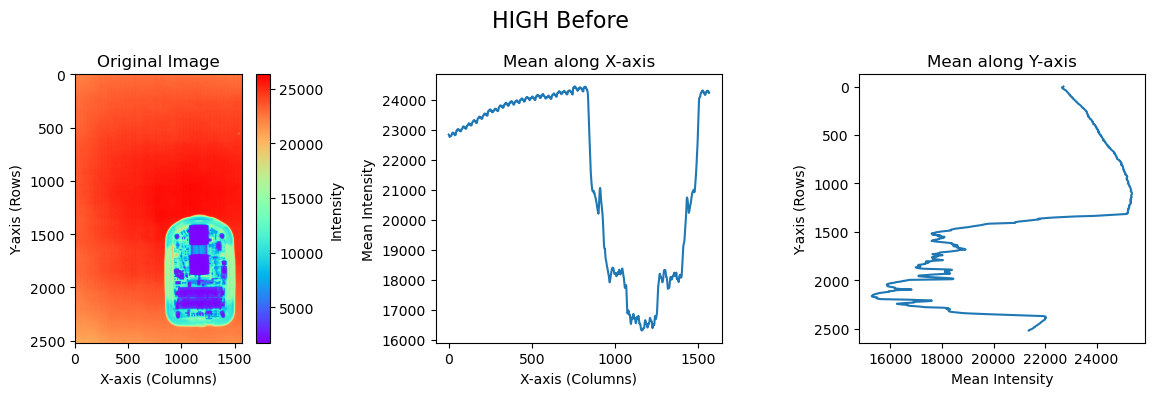

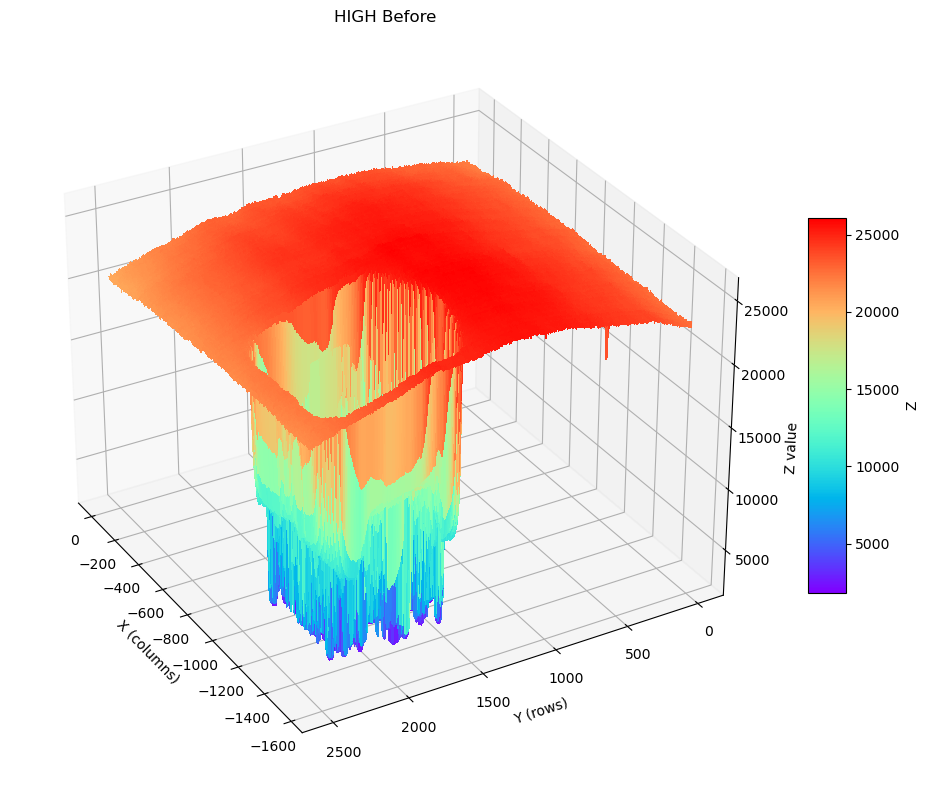

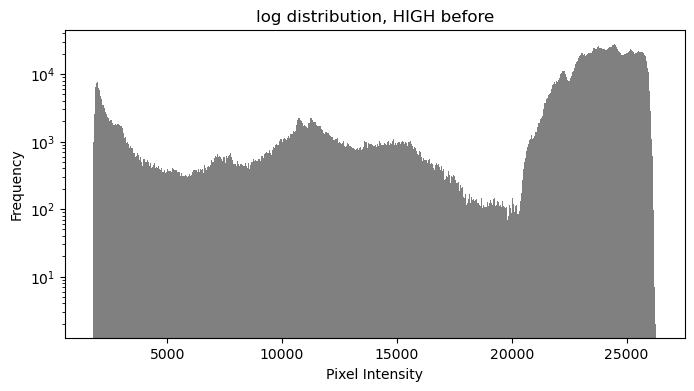

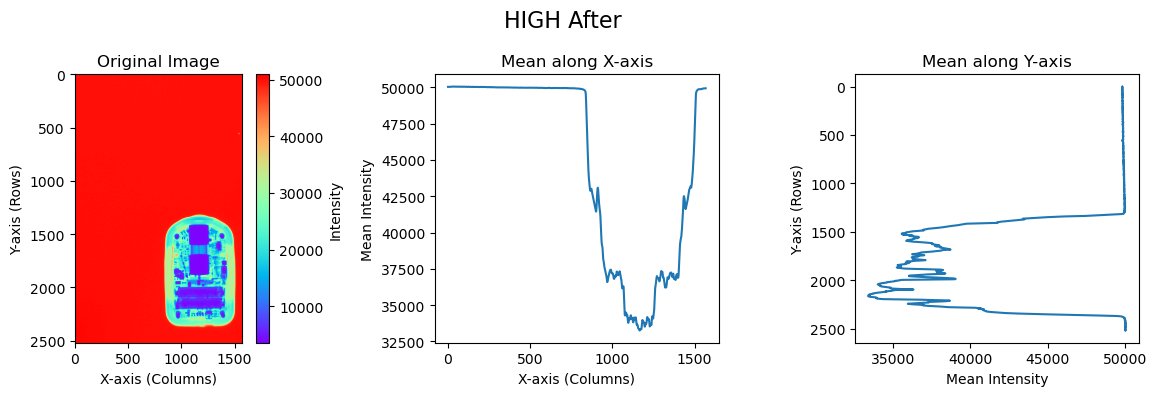

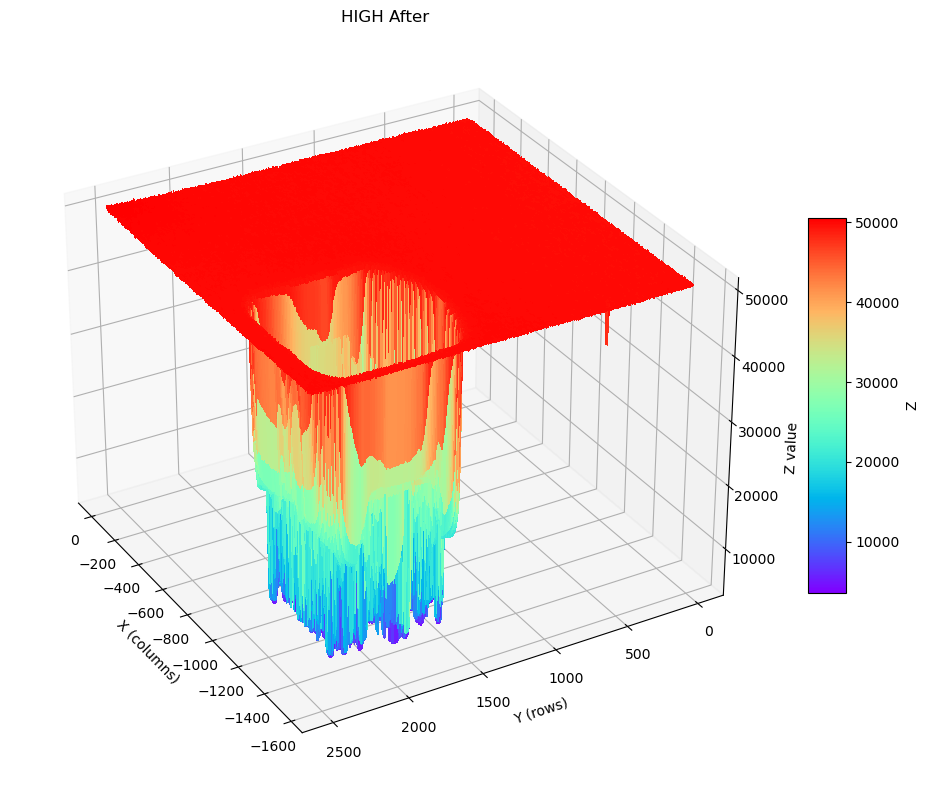

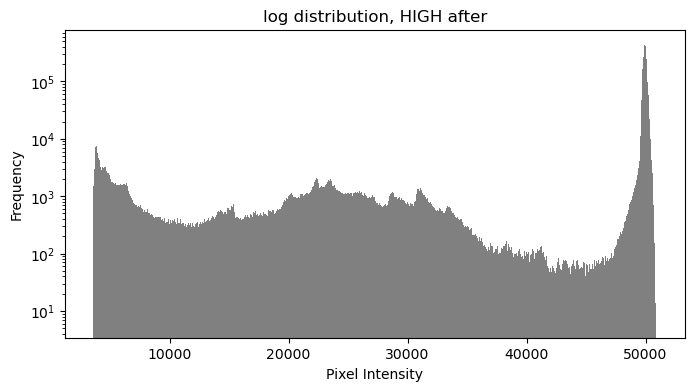

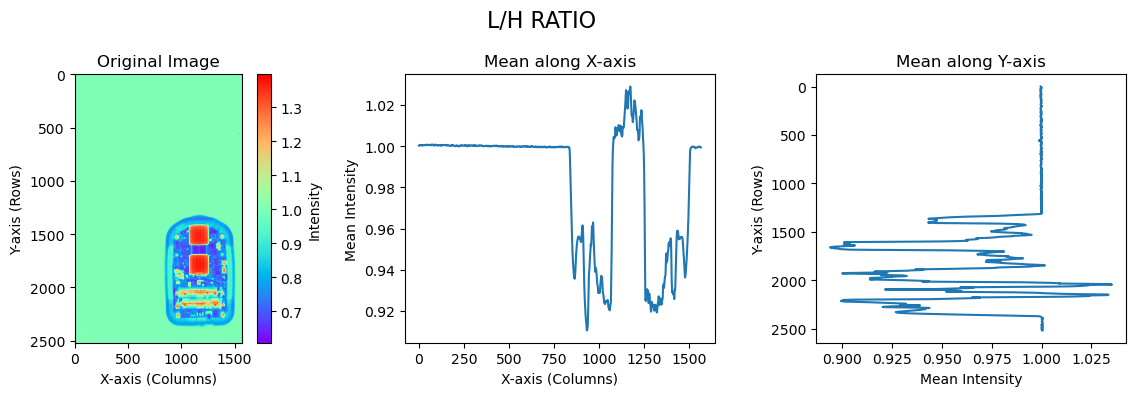

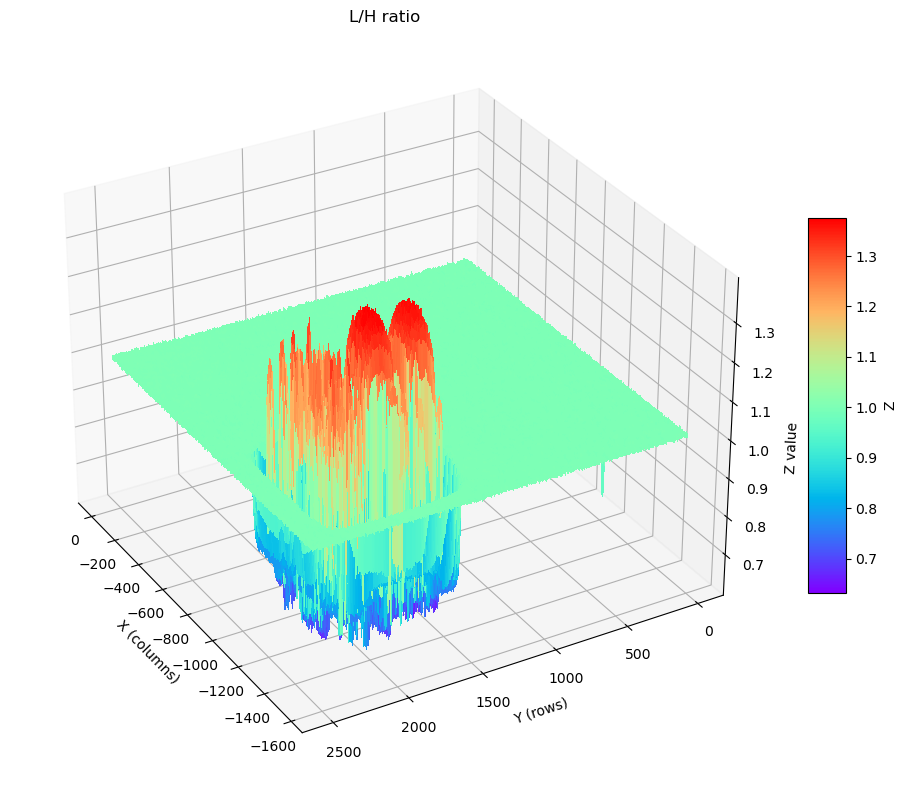

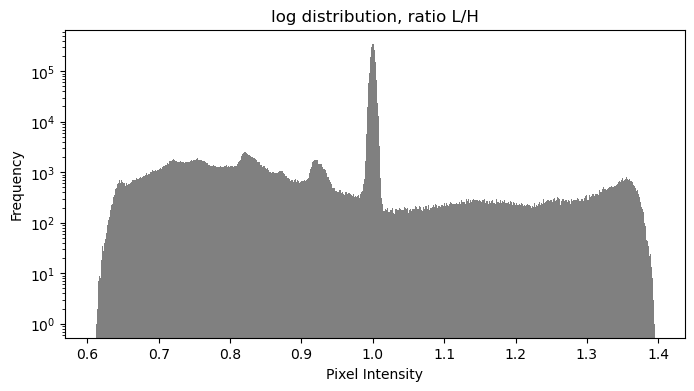

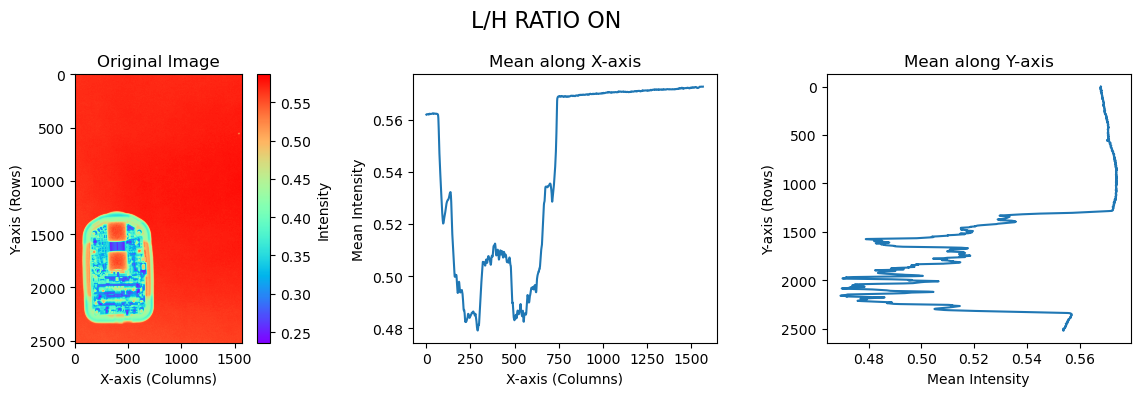

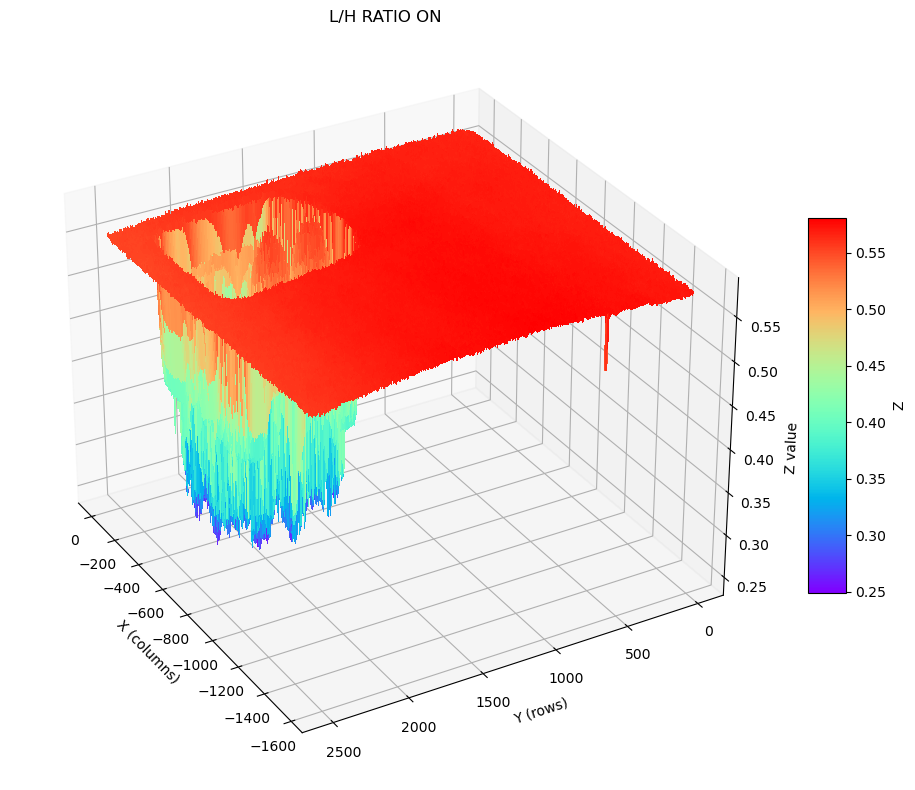

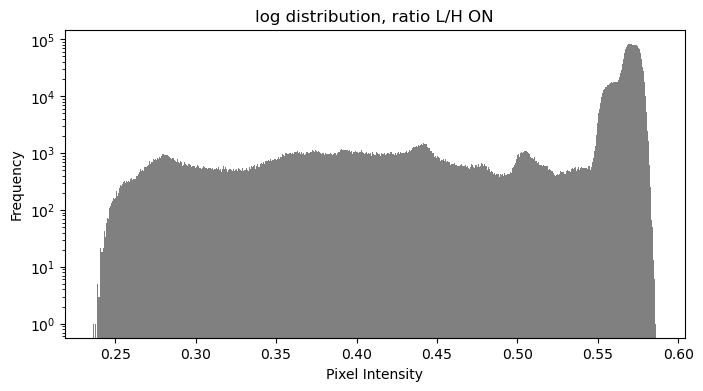

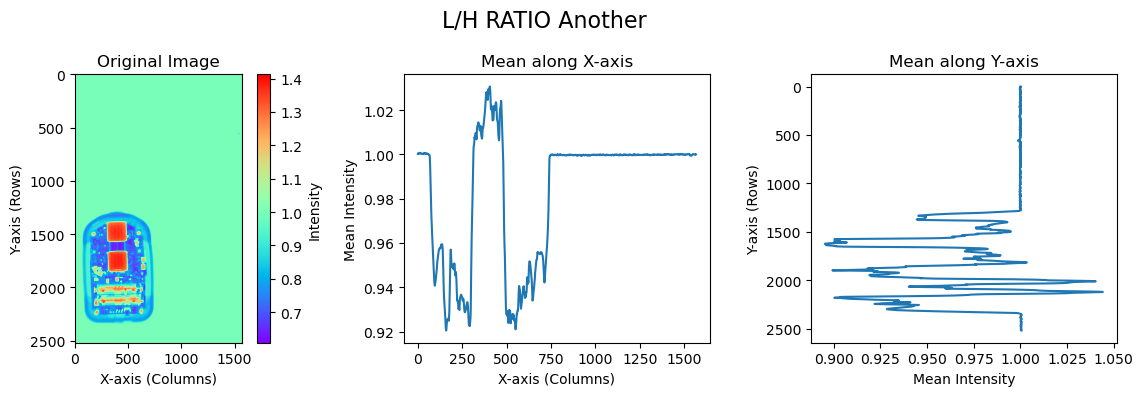

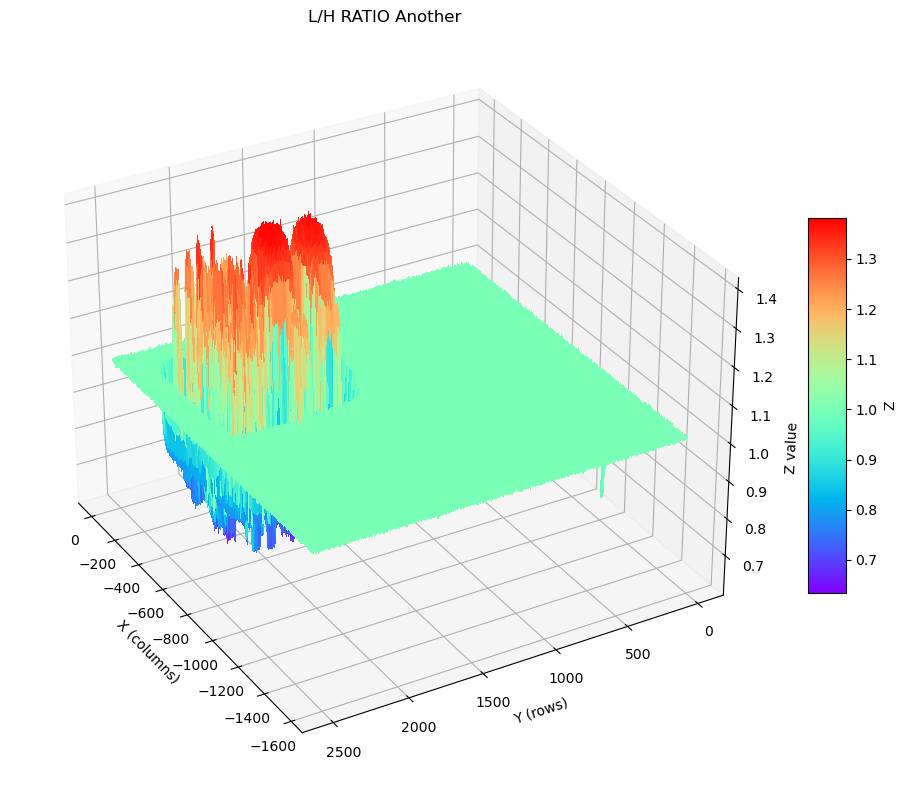

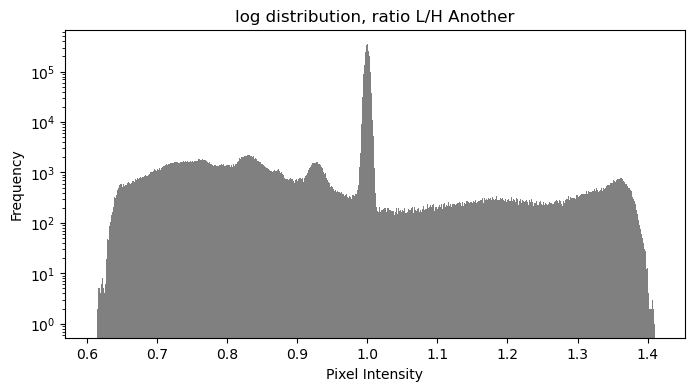

In [14]:

sample = "39"
sample_dir = "rightdown"
raw_file_low = f"output/{sample_dir}/{sample}.raw.low"
raw_file_high = f"output/{sample_dir}/{sample}.raw.high"

array_low_before = np.fromfile(raw_file_low, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_low_before, "LOW Before")
img_show_surface(array_low_before, "LOW Before")
show_distribution_log_scale(array_low_before, "log distribution, LOW before")

array_low_after = dexa_correction.correct_image(array_low_before, array_correction_low)

img_show(array_low_after, "LOW After")
img_show_surface(array_low_after, "LOW After")
show_distribution_log_scale(array_low_after, "log distribution, LOW after")

array_high_before = np.fromfile(raw_file_high, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_high_before, "HIGH Before")
img_show_surface(array_high_before, "HIGH Before")
show_distribution_log_scale(array_high_before, "log distribution, HIGH before")

array_high_after = dexa_correction.correct_image(array_high_before, array_correction_high)

img_show(array_high_after, "HIGH After")
img_show_surface(array_high_after, "HIGH After")
show_distribution_log_scale(array_high_after, "log distribution, HIGH after")

array_ratio_low_over_high = array_low_after / array_high_after

img_show(array_ratio_low_over_high, "L/H RATIO")
img_show_surface(array_ratio_low_over_high, "L/H ratio")
show_distribution_log_scale(array_ratio_low_over_high, "log distribution, ratio L/H")

ratio_file_on = f"output/{sample_dir}/on/{sample}.raw.ratio"
array_ratio_on = np.fromfile(ratio_file_on, dtype=np.float32).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)
img_show(array_ratio_on, "L/H RATIO ON")
img_show_surface(array_ratio_on, "L/H RATIO ON")
show_distribution_log_scale(array_ratio_on, "log distribution, ratio L/H ON")

ratio_file = f"output/leftdown/{sample}.raw.ratio"
#ratio_file = f"output/{sample_dir}/{sample}.raw.ratio"
array_ratio_another = np.fromfile(ratio_file, dtype=np.float32).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)
img_show(array_ratio_another, "L/H RATIO Another")
img_show_surface(array_ratio_another, "L/H RATIO Another")
show_distribution_log_scale(array_ratio_another, "log distribution, ratio L/H Another")



## Jensen Shannon Distance

In [15]:
from jensen_shannon_distance import jensen_shannon_distance_of_two_images, jensen_shannon_distance_of_two_images_float

def build_filename_pairs(filename_prefix, filename_suffix):
    list_compare = []
    count_image = 40
    for n1 in range(0, count_image):
        filename1 = f"{filename_prefix}{n1}{filename_suffix}"
        for n2 in range(n1 + 1, count_image):
            filename2 = f"{filename_prefix}{n2}{filename_suffix}"
            list_compare.append((filename1, filename2))
    
    return list_compare

dir_compare = "leftdown"
list_compare_low_off  = build_filename_pairs(f"output/{dir_compare}/",    ".raw.low")
list_compare_high_off = build_filename_pairs(f"output/{dir_compare}/",    ".raw.high")
list_compare_low_cor  = build_filename_pairs(f"output/{dir_compare}/",    ".raw.low.cor")
list_compare_high_cor = build_filename_pairs(f"output/{dir_compare}/",    ".raw.high.cor")
list_compare_low_on   = build_filename_pairs(f"output/{dir_compare}/on/", ".raw.low")
list_compare_high_on  = build_filename_pairs(f"output/{dir_compare}/on/", ".raw.high")


list_compare_ratio_cor  = build_filename_pairs(f"output/{dir_compare}/", ".raw.ratio")
list_compare_ratio_on  = build_filename_pairs(f"output/{dir_compare}/on/", ".raw.ratio")

list_compare_ratio_sum_cor  = list_compare_ratio_cor + build_filename_pairs(f"output/rightup/", ".raw.ratio")
list_compare_ratio_sum_on  = list_compare_ratio_on + build_filename_pairs(f"output/rightup/on/", ".raw.ratio")

import multiprocessing

pool = multiprocessing.Pool()

list_distance_low_off = pool.map(jensen_shannon_distance_of_two_images, list_compare_low_off)
print(f"Mean distance for LOW  OFF   = {np.mean(list_distance_low_off):.6f},  std={np.std(list_distance_low_off):.6f}")

list_distance_low_cor = pool.map(jensen_shannon_distance_of_two_images, list_compare_low_cor)
print(f"Mean distance for LOW  COR   = {np.mean(list_distance_low_cor):.6f},  std={np.std(list_distance_low_cor):.6f}")

list_distance_low_on = pool.map(jensen_shannon_distance_of_two_images, list_compare_low_on)
print(f"Mean distance for LOW  ON    = {np.mean(list_distance_low_on):.6f},  std={np.std(list_distance_low_on):.6f}")

list_distance_high_off = pool.map(jensen_shannon_distance_of_two_images, list_compare_high_off)
print(f"Mean distance for HIGH OFF   = {np.mean(list_distance_high_off):.6f},  std={np.std(list_distance_high_off):.6f}")

list_distance_high_cor = pool.map(jensen_shannon_distance_of_two_images, list_compare_high_cor)
print(f"Mean distance for HIGH COR   = {np.mean(list_distance_high_cor):.6f},  std={np.std(list_distance_high_cor):.6f}")

list_distance_high_on = pool.map(jensen_shannon_distance_of_two_images, list_compare_high_on)
print(f"Mean distance for HIGH ON    = {np.mean(list_distance_high_on):.6f},  std={np.std(list_distance_high_on):.6f}")

list_distance_ratio_cor = pool.map(jensen_shannon_distance_of_two_images_float, list_compare_ratio_cor)
print(f"Mean distance for RATIO COR  = {np.mean(list_distance_ratio_cor):.6f},  std={np.std(list_distance_ratio_cor):.6f}")

list_distance_ratio_on = pool.map(jensen_shannon_distance_of_two_images_float, list_compare_ratio_on)
print(f"Mean distance for RATIO ON   = {np.mean(list_distance_ratio_on):.6f},  std={np.std(list_distance_ratio_on):.6f}")


list_distance_ratio_sum_cor = pool.map(jensen_shannon_distance_of_two_images_float, list_compare_ratio_sum_cor)
print(f"Mean distance for RATIO S COR= {np.mean(list_distance_ratio_sum_cor):.6f},  std={np.std(list_distance_ratio_sum_cor):.6f}")

list_distance_ratio_sum_on = pool.map(jensen_shannon_distance_of_two_images_float, list_compare_ratio_sum_on)
print(f"Mean distance for RATIO S ON = {np.mean(list_distance_ratio_sum_on):.6f},  std={np.std(list_distance_ratio_sum_on):.6f}")

pool.close()
pool.join()



Mean distance for LOW  OFF   = 0.046911,  std=0.004544
Mean distance for LOW  COR   = 0.056432,  std=0.000334
Mean distance for LOW  ON    = 0.057766,  std=0.033029
Mean distance for HIGH OFF   = 0.060738,  std=0.006171
Mean distance for HIGH COR   = 0.057011,  std=0.000276
Mean distance for HIGH ON    = 0.065379,  std=0.020864
Mean distance for RATIO COR  = 0.040937,  std=0.000188
Mean distance for RATIO ON   = 0.035679,  std=0.007338
Mean distance for RATIO S COR= 0.041081,  std=0.000421
Mean distance for RATIO S ON = 0.037988,  std=0.009692
